# Exploratory Data Analysis - Financial Fraud Detection

This notebook performs comprehensive exploratory data analysis on the financial fraud detection dataset.

## Dataset Overview
- **Features**: 31 columns (Time, V1-V28, Amount, Class)
- **Target**: Class (0 = legitimate, 1 = fraud)
- **Challenge**: Highly imbalanced dataset with rare fraud cases


## 1. Import Libraries

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Statistical analysis
from scipy import stats
from scipy.stats import chi2_contingency
import math

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load and Initial Data Inspection

In [ ]:

df = pd.read_csv('../data/raw/creditcard.csv')  

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset loaded successfully!
Dataset shape: (284807, 31)
Memory usage: 67.36 MB


In [ ]:
print("=== DATASET INFO ===")
print(df.info())
print("\n=== FIRST 5 ROWS ===")
display(df.head())
print("\n=== LAST 5 ROWS ===")
display(df.tail())

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



=== LAST 5 ROWS ===


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,-0.915427,-1.040458,-0.031513,-0.188093,-0.084316,0.041333,-0.302620,-0.660377,0.167430,-0.256117,0.382948,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [4]:
# Statistical summary
print("=== STATISTICAL SUMMARY ===")
display(df.describe())

=== STATISTICAL SUMMARY ===


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 3. Data Quality Assessment

In [ ]:
print("=== MISSING VALUES ===")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
if missing_values.sum() == 0:
    print("No missing values found!")
    
print(f"\nTotal missing values: {missing_values.sum()}")
print(f"Percentage of missing values: {(missing_values.sum() / df.shape[0]) * 100:.2f}%")

=== MISSING VALUES ===
Series([], dtype: int64)
No missing values found!

Total missing values: 0
Percentage of missing values: 0.00%


In [ ]:
print("=== DUPLICATE RECORDS ===")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
print(f"Percentage of duplicates: {(duplicates / df.shape[0]) * 100:.2f}%")

if duplicates > 0:
    print("\nDuplicate rows:")
    display(df[df.duplicated()].head())

=== DUPLICATE RECORDS ===
Number of duplicate rows: 1081
Percentage of duplicates: 0.38%

Duplicate rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,-0.484688,0.872490,0.851636,-0.571745,0.100974,-1.519772,-0.284376,-0.310524,-0.404248,-0.823374,-0.290348,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,-0.482474,0.871800,0.853447,-0.571822,0.102252,-1.519991,-0.285912,-0.309633,-0.403902,-0.823743,-0.283264,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,-0.243289,0.578063,0.674730,-0.534231,0.446601,1.122885,-1.768001,1.241157,-2.449500,-1.747255,-0.335520,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,-0.243289,0.578063,0.674730,-0.534231,0.446601,1.122885,-1.768001,1.241157,-2.449500,-1.747255,-0.335520,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,-0.243289,0.578063,0.674730,-0.534231,0.446601,1.122885,-1.768001,1.241157,-2.449500,-1.747255,-0.335520,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0


In [ ]:
print("=== DATA TYPES AND UNIQUE VALUES ===")
data_types_summary = pd.DataFrame({
    'Column': df.columns,
    'Data_Type': df.dtypes,
    'Unique_Values': df.nunique(),
    'Sample_Values': [df[col].unique()[:3] for col in df.columns]
})
display(data_types_summary)

=== DATA TYPES AND UNIQUE VALUES ===


,Column,Data_Type,Unique_Values,Sample_Values
Time,Time,float64,124592,"[0.0, 1.0, 2.0]"
V1,V1,float64,275663,"[-1.3598071336738, 1.19185711131486, -1.358354..."
V2,V2,float64,275663,"[-0.0727811733098497, 0.26615071205963, -1.340..."
V3,V3,float64,275663,"[2.53634673796914, 0.16648011335321, 1.7732093..."
V4,V4,float64,275663,"[1.37815522427443, 0.448154078460911, 0.379779..."
V5,V5,float64,275663,"[-0.338320769942518, 0.0600176492822243, -0.50..."
V6,V6,float64,275663,"[0.462387777762292, -0.0823608088155687, 1.800..."
V7,V7,float64,275663,"[0.239598554061257, -0.0788029833323113, 0.791..."
V8,V8,float64,275663,"[0.0986979012610507, 0.0851016549148104, 0.247..."
V9,V9,float64,275663,"[0.363786969611213, -0.255425128109186, -1.514..."


## 4. Target Variable Analysis (Class Imbalance)

In [8]:
# Analyze class distribution
print("=== CLASS DISTRIBUTION ===")
class_counts = df['Class'].value_counts()
class_percentages = df['Class'].value_counts(normalize=True) * 100

print("Count of each class:")
for class_val, count in class_counts.items():
    class_name = 'Legitimate' if class_val == 0 else 'Fraud'
    percentage = class_percentages[class_val]
    print(f"  {class_name} (Class {class_val}): {count:,} ({percentage:.4f}%)")

fraud_ratio = class_counts[1] / class_counts[0]
print(f"\nFraud to Legitimate ratio: 1:{fraud_ratio:.0f}")
print(f"Imbalance ratio: {fraud_ratio:.6f}")

=== CLASS DISTRIBUTION ===
Count of each class:
  Legitimate (Class 0): 284,315 (99.8273%)
  Fraud (Class 1): 492 (0.1727%)

Fraud to Legitimate ratio: 1:0
Imbalance ratio: 0.001730


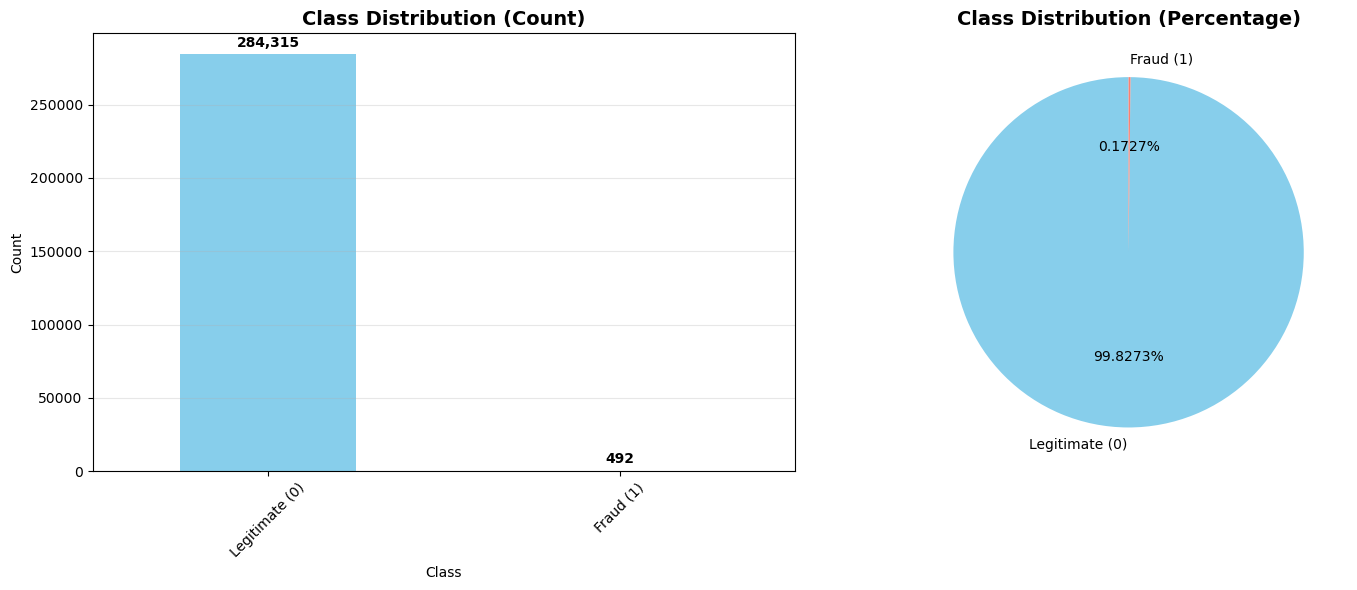

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# for bar plot
class_counts.plot(kind='bar', ax=ax1, color=['skyblue', 'salmon'])
ax1.set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Class')
ax1.set_ylabel('Count')
ax1.set_xticklabels(['Legitimate (0)', 'Fraud (1)'], rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, v in enumerate(class_counts.values):
    ax1.text(i, v + max(class_counts.values) * 0.01, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# for pie chart
colors = ['skyblue', 'salmon']
labels = ['Legitimate (0)', 'Fraud (1)']
ax2.pie(class_counts.values, labels=labels, autopct='%1.4f%%', colors=colors, startangle=90)
ax2.set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Feature Analysis

In [ ]:
print("=== TIME FEATURE ANALYSIS ===")
print(f"Time range: {df['Time'].min():.0f} to {df['Time'].max():.0f} seconds")
print(f"Time span: {(df['Time'].max() - df['Time'].min()) / 3600:.1f} hours")
print(f"Time span: {(df['Time'].max() - df['Time'].min()) / (3600 * 24):.1f} days")

# Converting time to hours for better understanding
df['Time_hours'] = df['Time'] / 3600

print(f"\nTime statistics:")
print(df['Time_hours'].describe())

=== TIME FEATURE ANALYSIS ===
Time range: 0 to 172792 seconds
Time span: 48.0 hours
Time span: 2.0 days

Time statistics:
count    284807.000000
mean         26.337183
std          13.191152
min           0.000000
25%          15.055972
50%          23.525556
75%          38.700139
max          47.997778
Name: Time_hours, dtype: float64


In [ ]:
print("=== AMOUNT FEATURE ANALYSIS ===")
print(f"Amount statistics:")
print(df['Amount'].describe())

print(f"\nAmount by class:")
amount_by_class = df.groupby('Class')['Amount'].describe()
display(amount_by_class)

# zero amounts check
zero_amounts = (df['Amount'] == 0).sum()
print(f"\nTransactions with zero amount: {zero_amounts} ({(zero_amounts/len(df))*100:.2f}%)")

=== AMOUNT FEATURE ANALYSIS ===
Amount statistics:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Amount by class:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87



Transactions with zero amount: 1825 (0.64%)


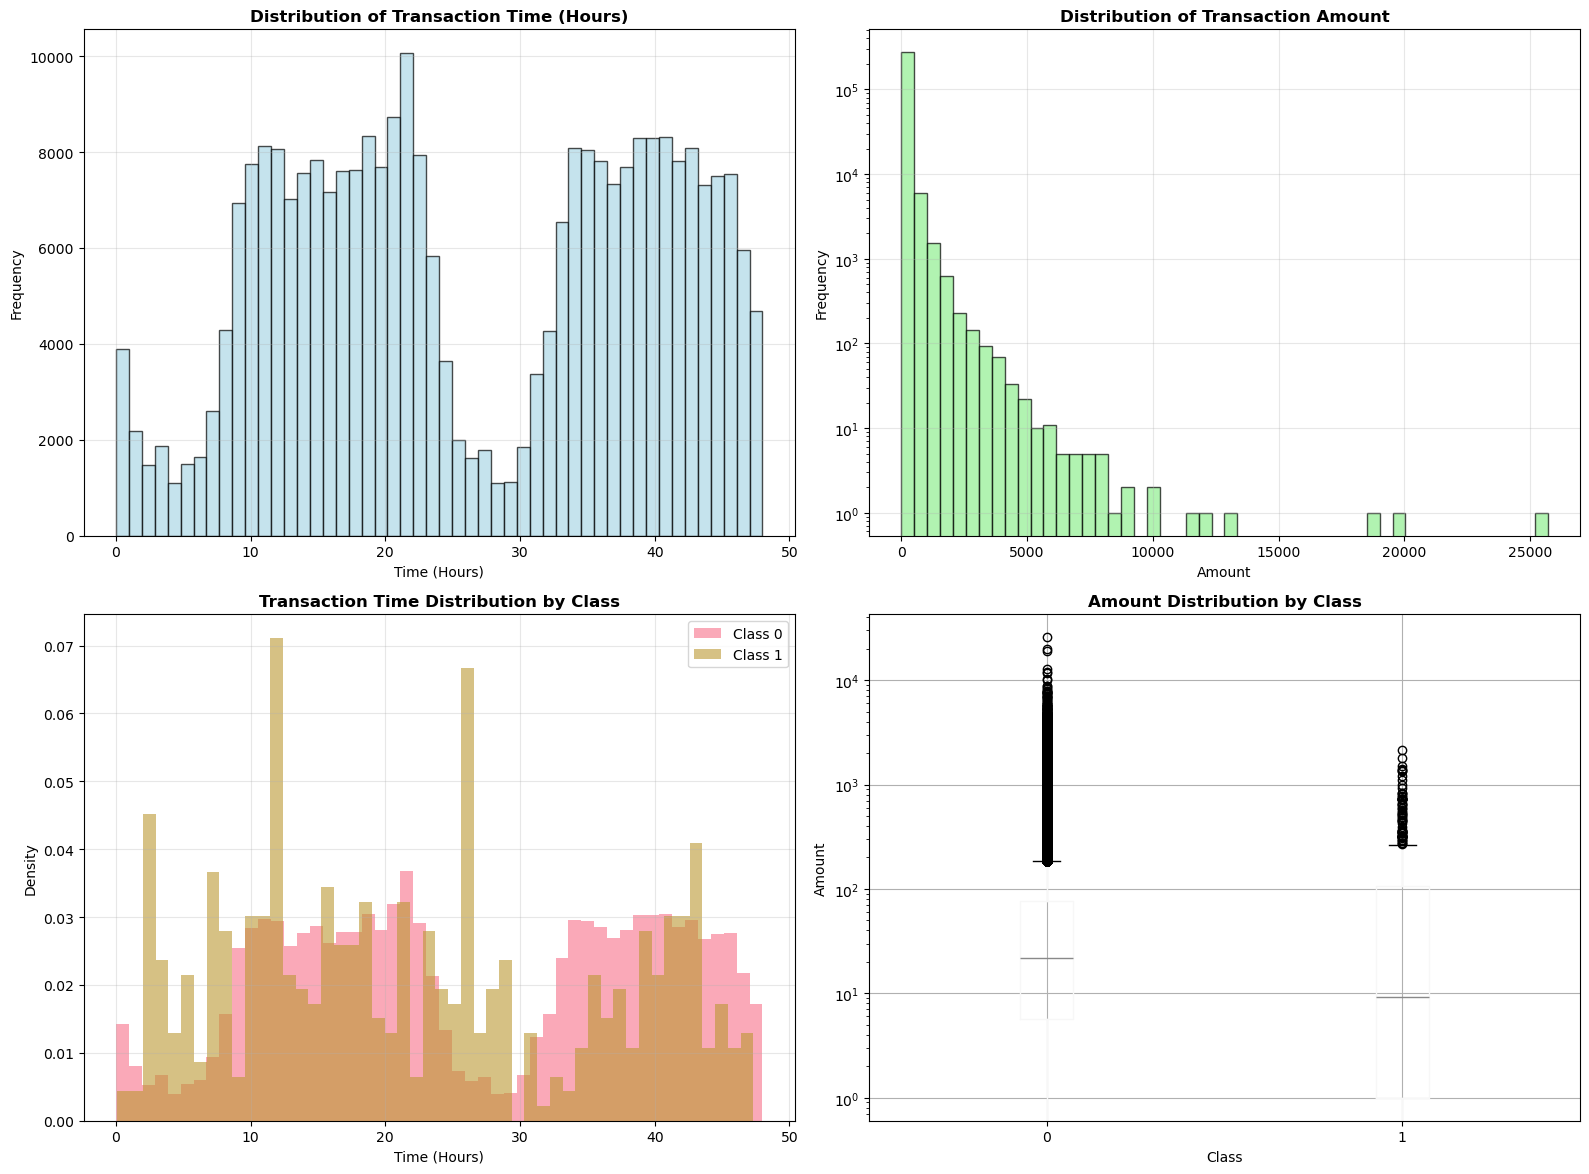

In [ ]:
# Visualization of Time and Amount distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Time distribution
df['Time_hours'].hist(bins=50, ax=axes[0,0], color='lightblue', alpha=0.7, edgecolor='black')
axes[0,0].set_title('Distribution of Transaction Time (Hours)', fontweight='bold')
axes[0,0].set_xlabel('Time (Hours)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].grid(alpha=0.3)

# Amount distribution 
df[df['Amount'] > 0]['Amount'].hist(bins=50, ax=axes[0,1], color='lightgreen', alpha=0.7, edgecolor='black')
axes[0,1].set_title('Distribution of Transaction Amount', fontweight='bold')
axes[0,1].set_xlabel('Amount')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_yscale('log')
axes[0,1].grid(alpha=0.3)

# Time by class
for class_val in [0, 1]:
    class_data = df[df['Class'] == class_val]['Time_hours']
    axes[1,0].hist(class_data, bins=50, alpha=0.6, 
                  label=f'Class {class_val}', density=True)
axes[1,0].set_title('Transaction Time Distribution by Class', fontweight='bold')
axes[1,0].set_xlabel('Time (Hours)')
axes[1,0].set_ylabel('Density')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# Amount by class in boxplot
df.boxplot(column='Amount', by='Class', ax=axes[1,1])
axes[1,1].set_title('Amount Distribution by Class', fontweight='bold')
axes[1,1].set_xlabel('Class')
axes[1,1].set_ylabel('Amount')
axes[1,1].set_yscale('log')

plt.suptitle('')  #for automatic title removal
plt.tight_layout()
plt.show()

## 6. PCA Features (V1-V28) Analysis

In [ ]:
# Principal Component Analysis (PCA) feature columns
pca_features = [f'V{i}' for i in range(1, 29)]

print("=== PCA FEATURES ANALYSIS ===")
print(f"Number of PCA features: {len(pca_features)}")
print(f"\nPCA features statistics:")
display(df[pca_features].describe())

=== PCA FEATURES ANALYSIS ===
Number of PCA features: 28

PCA features statistics:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
count,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05
mean,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16
std,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01
min,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01
25%,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02
50%,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02
75%,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02
max,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01


In [14]:
# Distribution plots for PCA features
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df_filtered = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]]
    nRow, nCol = df_filtered.shape
    columnNames = list(df_filtered)
    nGraphRow = math.ceil(min(nCol, nGraphShown) / nGraphPerRow)
    
    plt.figure(num=None, figsize=(6 * nGraphPerRow, 8 * nGraphRow), dpi=80, facecolor='w', edgecolor='k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df_filtered.iloc[:, i]
        if not np.issubdtype(columnDf.dtype, np.number):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist(bins=30, alpha=0.7, edgecolor='black')
        plt.ylabel('Counts')
        plt.xticks(rotation=90)
        plt.title(f'{columnNames[i]} (column {i})', fontweight='bold')
        plt.grid(alpha=0.3)
    plt.tight_layout(pad=1.0, w_pad=1.0, h_pad=1.0)
    plt.show()

# Plot distributions for first 10 features
print("Distribution plots for features (Time, V1-V8, Amount):")
features_to_plot = ['Time'] + [f'V{i}' for i in range(1, 9)] + ['Amount']
plotPerColumnDistribution(df[features_to_plot], 10, 5)

Distribution plots for features (Time, V1-V8, Amount):


<Figure size 2400x0 with 0 Axes>

## 7. Correlation Analysis

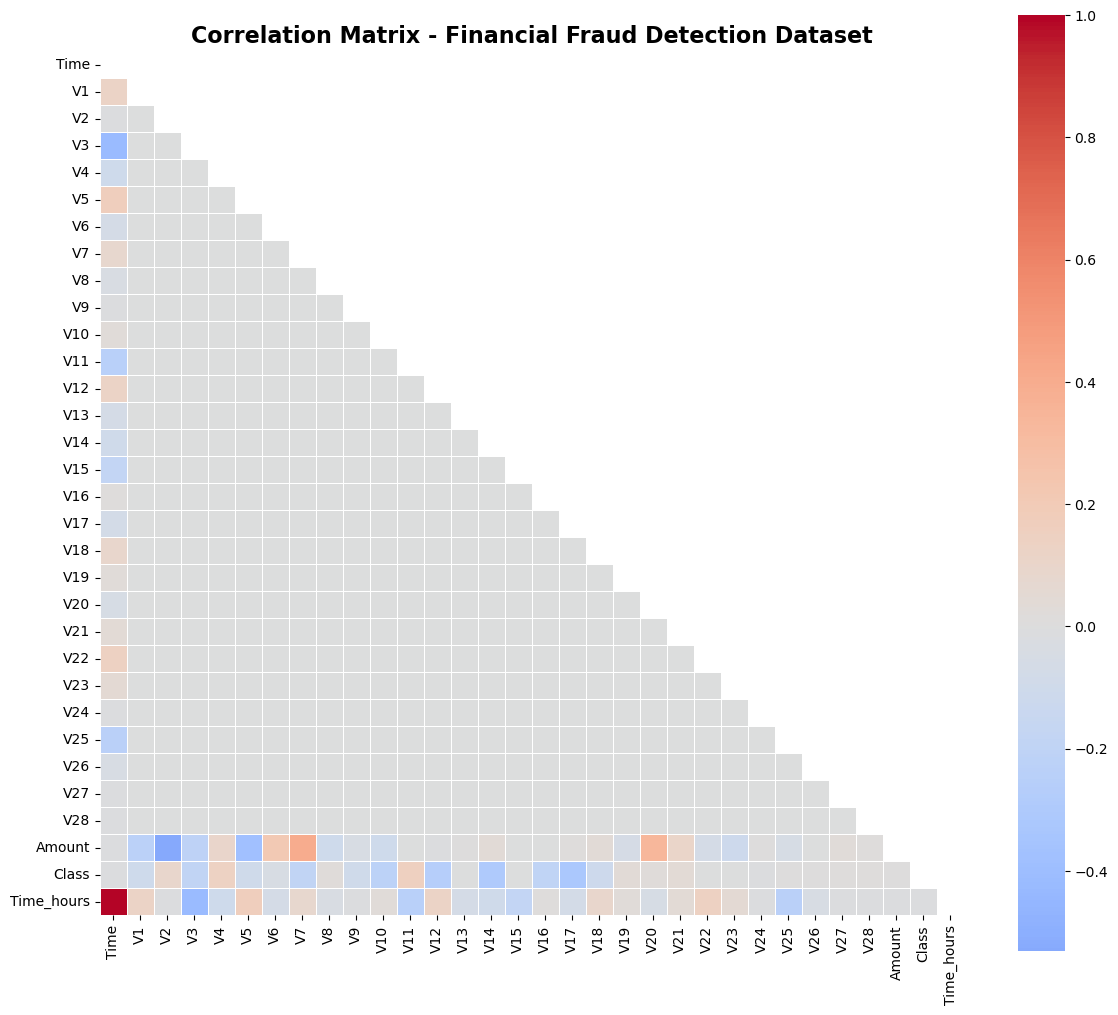


=== TOP 10 HIGHLY CORRELATED FEATURE PAIRS ===
Time <-> Time_hours: 1.000
Time_hours <-> Time: 1.000


In [ ]:
def plotCorrelationMatrix(df, graphWidth):
    # Drop columns with any NaN values and keep columns with more than 1 unique value
    df_clean = df.dropna(axis='columns')
    df_clean = df_clean[[col for col in df_clean.columns if df_clean[col].nunique() > 1]]
    
    if df_clean.shape[1] < 2:
        print(f'No correlation plots shown: The number of non-NaN or constant columns ({df_clean.shape[1]}) is less than 2')
        return
    
    corr = df_clean.corr()
    
    plt.figure(figsize=(graphWidth, graphWidth))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": .8})
    plt.title('Correlation Matrix - Financial Fraud Detection Dataset', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Show highly correlated pairs
    corr_pairs = corr.unstack().sort_values(ascending=False)
    high_corr = corr_pairs[(corr_pairs > 0.5) & (corr_pairs < 1.0)].head(10)
    
    print("\n=== TOP 10 HIGHLY CORRELATED FEATURE PAIRS ===")
    for pair, correlation in high_corr.items():
        print(f"{pair[0]} <-> {pair[1]}: {correlation:.3f}")

# Plot correlation matrix
plotCorrelationMatrix(df, 12)

## 8. Feature Relationships with Target Variable

In [16]:
# Correlation with target variable
feature_target_corr = df.corr()['Class'].abs().sort_values(ascending=False)
print("=== CORRELATION WITH TARGET VARIABLE (CLASS) ===")
print("Features most correlated with fraud:")
print(feature_target_corr.head(15))

=== CORRELATION WITH TARGET VARIABLE (CLASS) ===
Features most correlated with fraud:
Class    1.000000
V17      0.326481
V14      0.302544
V12      0.260593
V10      0.216883
V16      0.196539
V3       0.192961
V7       0.187257
V11      0.154876
V4       0.133447
V18      0.111485
V1       0.101347
V9       0.097733
V5       0.094974
V2       0.091289
Name: Class, dtype: float64


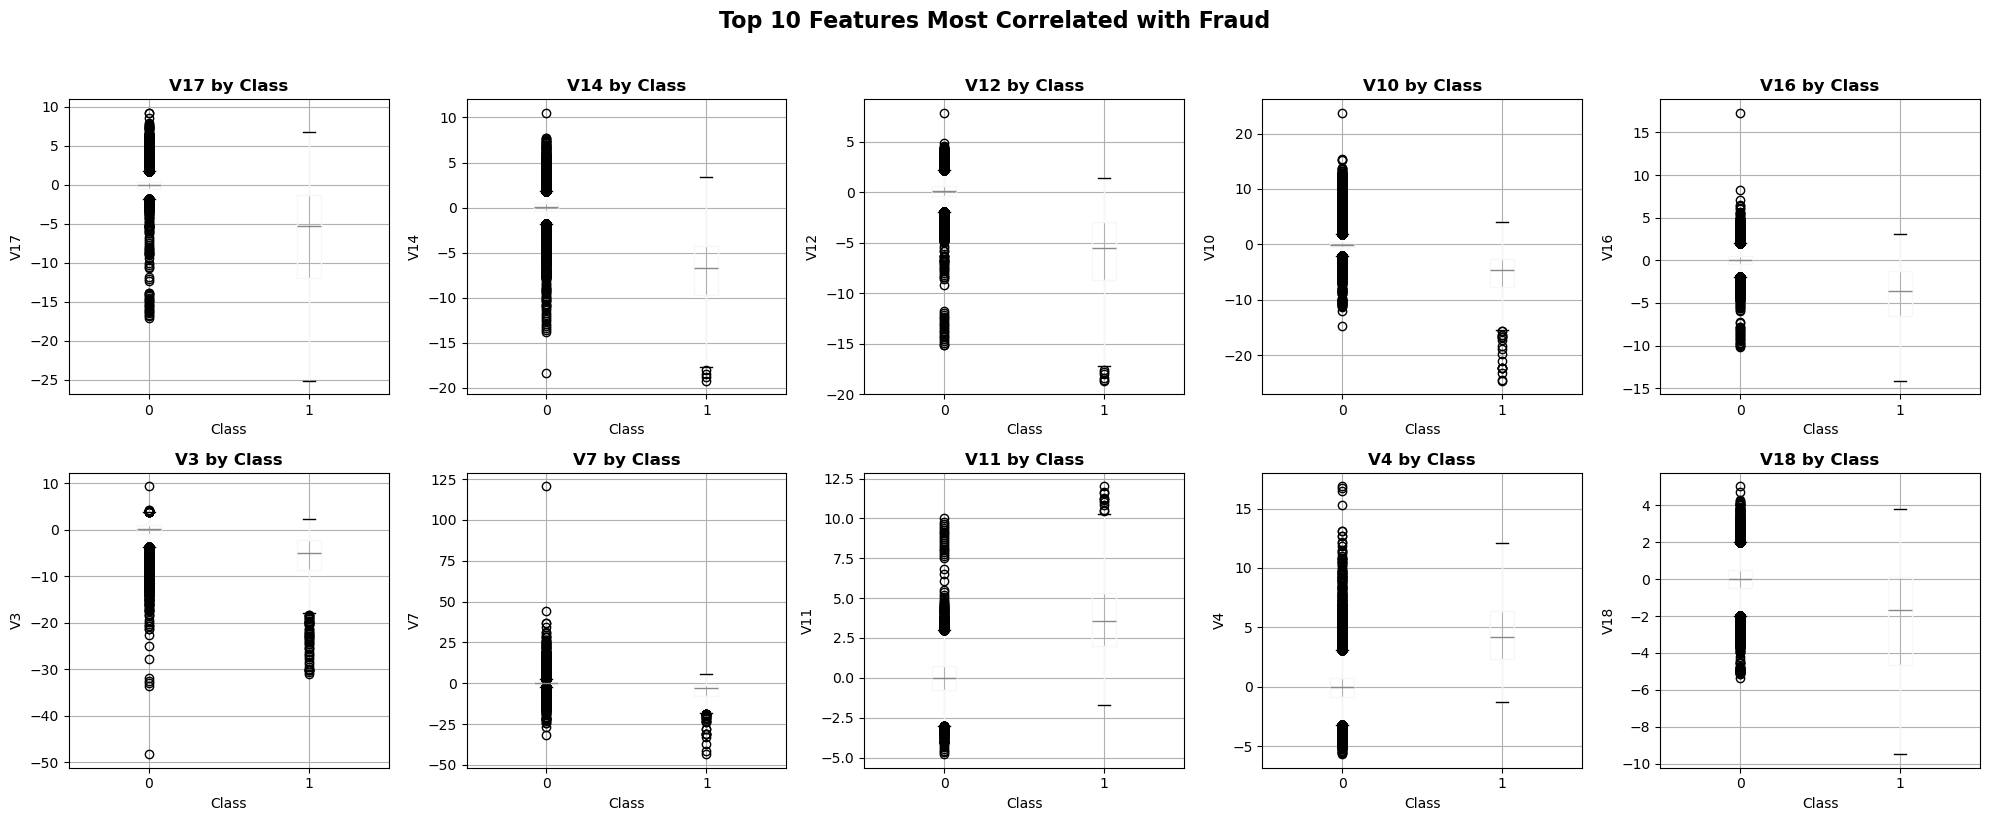

In [17]:
# Plot top features correlated with target
top_features = feature_target_corr.drop('Class').head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for i, feature in enumerate(top_features):
    # Box plot for each class
    df.boxplot(column=feature, by='Class', ax=axes[i])
    axes[i].set_title(f'{feature} by Class', fontweight='bold')
    axes[i].set_xlabel('Class')
    axes[i].set_ylabel(feature)

plt.suptitle('Top 10 Features Most Correlated with Fraud', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Statistical Tests

In [18]:
# Statistical significance tests for key features
print("=== STATISTICAL SIGNIFICANCE TESTS ===")
print("Testing if feature distributions differ significantly between classes\n")

# Select top features for testing
test_features = ['Amount', 'Time'] + top_features[:8]

results = []
for feature in test_features:
    # Get data for each class
    legitimate = df[df['Class'] == 0][feature]
    fraud = df[df['Class'] == 1][feature]
    
    # Perform Mann-Whitney U test (non-parametric)
    statistic, p_value = stats.mannwhitneyu(legitimate, fraud, alternative='two-sided')
    
    # Effect size (Cohen's d)
    pooled_std = np.sqrt(((len(legitimate) - 1) * legitimate.var() + 
                         (len(fraud) - 1) * fraud.var()) / 
                        (len(legitimate) + len(fraud) - 2))
    cohens_d = abs(legitimate.mean() - fraud.mean()) / pooled_std
    
    results.append({
        'Feature': feature,
        'P_value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No',
        'Effect_Size': cohens_d
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('P_value')
display(results_df)

=== STATISTICAL SIGNIFICANCE TESTS ===
Testing if feature distributions differ significantly between classes



,Feature,P_value,Significant,Effect_Size
3,V14,1.471581e-260,Yes,7.643639
4,V12,8.416027e-247,Yes,6.499801
9,V11,4.910592e-226,Yes,3.775043
5,V10,9.611131e-222,Yes,5.350007
7,V3,1.211048e-219,Yes,4.735605
6,V16,1.808172e-156,Yes,4.826913
8,V7,1.464234e-146,Yes,4.590445
2,V17,9.219384e-124,Yes,8.317624
1,Time,4.386159e-10,Yes,0.296757
0,Amount,8.578472e-06,Yes,0.135618


## 10. Time-based Analysis

In [19]:
# Time-based fraud analysis
print("=== TIME-BASED FRAUD ANALYSIS ===")

# Create time bins
df['Time_bin'] = pd.cut(df['Time_hours'], bins=24, labels=False)
time_fraud_analysis = df.groupby('Time_bin').agg({
    'Class': ['count', 'sum', 'mean']
}).round(4)

time_fraud_analysis.columns = ['Total_Transactions', 'Fraud_Count', 'Fraud_Rate']
time_fraud_analysis = time_fraud_analysis.reset_index()

print("Fraud rate by time periods:")
display(time_fraud_analysis.head(10))

=== TIME-BASED FRAUD ANALYSIS ===
Fraud rate by time periods:


,Time_bin,Total_Transactions,Fraud_Count,Fraud_Rate
0,0,6180,4,0.0006
1,1,3397,34,0.0100
2,2,2763,17,0.0062
3,3,5197,26,0.0050
4,4,13058,20,0.0015
5,5,16802,45,0.0027
6,6,15314,18,0.0012
7,7,15867,27,0.0017
8,8,15667,26,0.0017
9,9,16597,22,0.0013


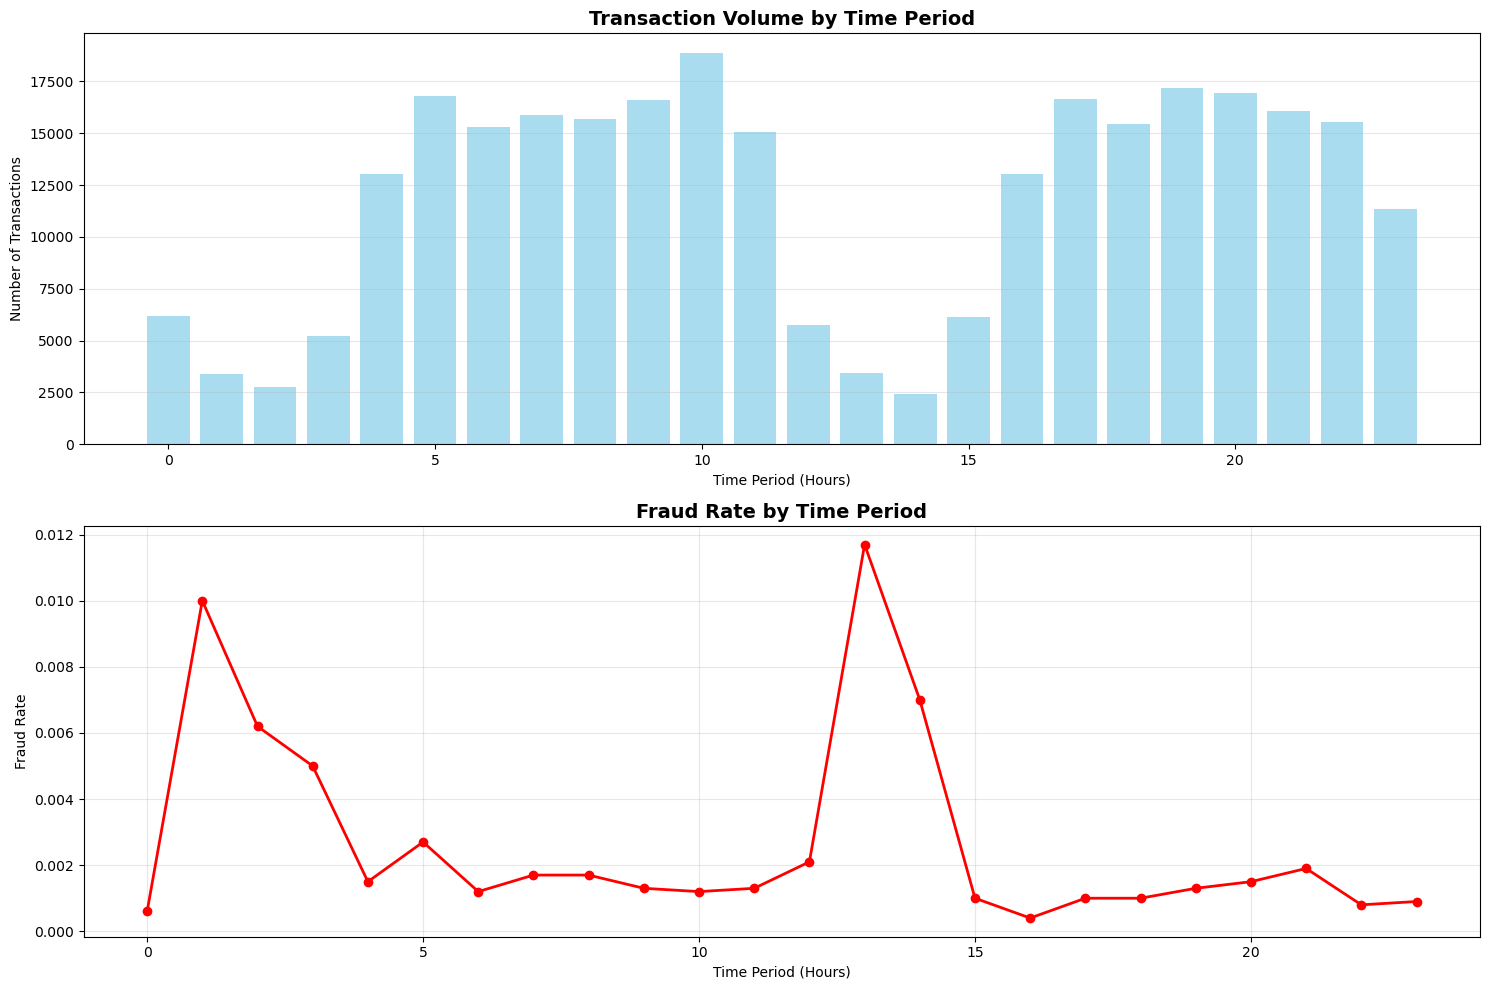

In [20]:
# Plot time-based fraud patterns
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Transaction volume over time
ax1.bar(time_fraud_analysis['Time_bin'], time_fraud_analysis['Total_Transactions'], 
        alpha=0.7, color='skyblue')
ax1.set_title('Transaction Volume by Time Period', fontweight='bold', fontsize=14)
ax1.set_xlabel('Time Period (Hours)')
ax1.set_ylabel('Number of Transactions')
ax1.grid(axis='y', alpha=0.3)

# Fraud rate over time
ax2.plot(time_fraud_analysis['Time_bin'], time_fraud_analysis['Fraud_Rate'], 
         marker='o', linewidth=2, markersize=6, color='red')
ax2.set_title('Fraud Rate by Time Period', fontweight='bold', fontsize=14)
ax2.set_xlabel('Time Period (Hours)')
ax2.set_ylabel('Fraud Rate')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Amount-based Analysis

In [21]:
# Amount-based fraud analysis
print("=== AMOUNT-BASED FRAUD ANALYSIS ===")

# Create amount bins
amount_bins = [0, 10, 50, 100, 500, 1000, 5000, df['Amount'].max()]
amount_labels = ['0-10', '10-50', '50-100', '100-500', '500-1K', '1K-5K', '5K+']
df['Amount_bin'] = pd.cut(df['Amount'], bins=amount_bins, labels=amount_labels, include_lowest=True)

amount_fraud_analysis = df.groupby('Amount_bin').agg({
    'Class': ['count', 'sum', 'mean']
}).round(4)

amount_fraud_analysis.columns = ['Total_Transactions', 'Fraud_Count', 'Fraud_Rate']
amount_fraud_analysis = amount_fraud_analysis.reset_index()

print("Fraud analysis by amount ranges:")
display(amount_fraud_analysis)

=== AMOUNT-BASED FRAUD ANALYSIS ===
Fraud analysis by amount ranges:


,Amount_bin,Total_Transactions,Fraud_Count,Fraud_Rate
0,0-10,100264,249,0.0025
1,10-50,90781,57,0.0006
2,50-100,37254,56,0.0015
3,100-500,47366,95,0.0020
4,500-1K,6202,26,0.0042
5,1K-5K,2885,9,0.0031
6,5K+,55,0,0.0000


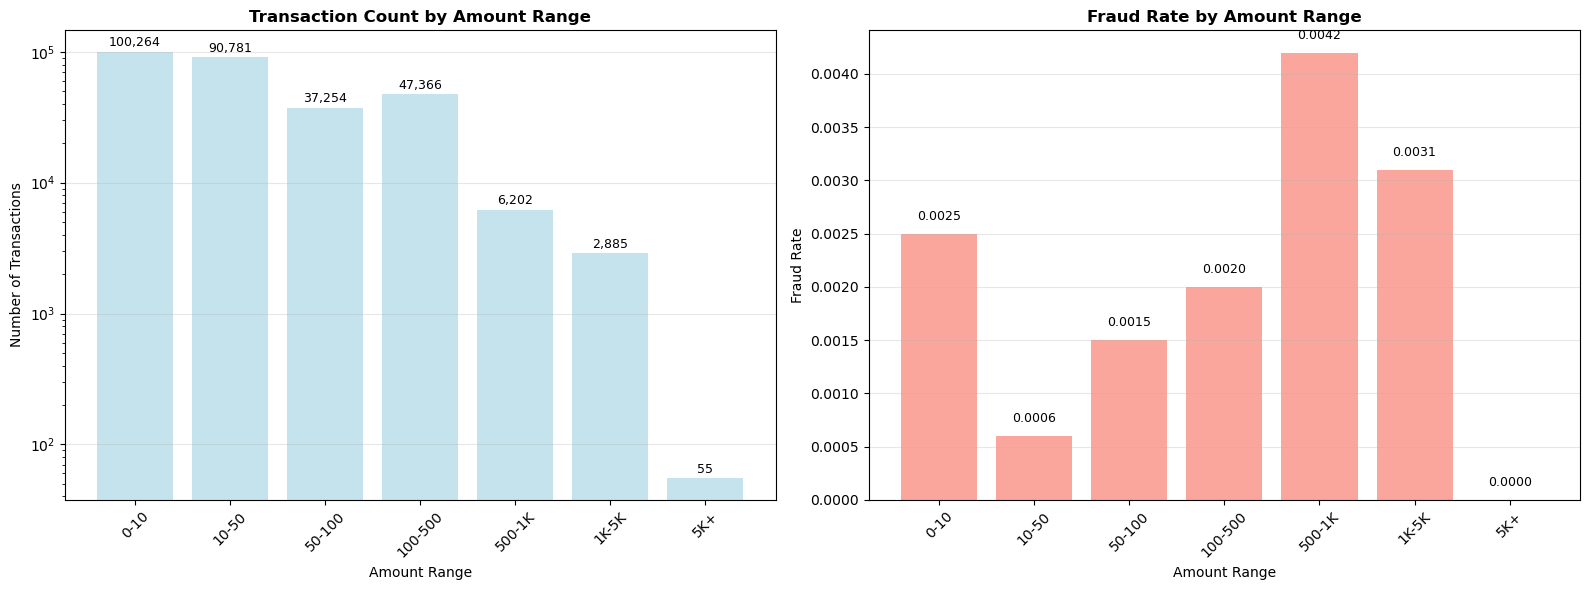

In [22]:
# Plot amount-based analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Transaction count by amount range
bars1 = ax1.bar(amount_fraud_analysis['Amount_bin'], amount_fraud_analysis['Total_Transactions'], 
               alpha=0.7, color='lightblue')
ax1.set_title('Transaction Count by Amount Range', fontweight='bold')
ax1.set_xlabel('Amount Range')
ax1.set_ylabel('Number of Transactions')
ax1.set_yscale('log')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height * 1.05,
             f'{int(height):,}', ha='center', va='bottom', fontsize=9)

# Fraud rate by amount range
bars2 = ax2.bar(amount_fraud_analysis['Amount_bin'], amount_fraud_analysis['Fraud_Rate'], 
               alpha=0.7, color='salmon')
ax2.set_title('Fraud Rate by Amount Range', fontweight='bold')
ax2.set_xlabel('Amount Range')
ax2.set_ylabel('Fraud Rate')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.0001,
             f'{height:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 12. Outlier Analysis

In [23]:
# Outlier detection using IQR method
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

print("=== OUTLIER ANALYSIS ===")

# Analyze outliers for Amount
amount_outliers, amount_lower, amount_upper = detect_outliers_iqr(df, 'Amount')
print(f"Amount outliers: {len(amount_outliers)} ({len(amount_outliers)/len(df)*100:.2f}%)")
print(f"Amount bounds: [{amount_lower:.2f}, {amount_upper:.2f}]")

# Check fraud rate in outliers
outlier_fraud_rate = amount_outliers['Class'].mean()
normal_fraud_rate = df[~df.index.isin(amount_outliers.index)]['Class'].mean()
print(f"Fraud rate in amount outliers: {outlier_fraud_rate:.4f}")
print(f"Fraud rate in normal amounts: {normal_fraud_rate:.4f}")
print(f"Outlier fraud rate is {outlier_fraud_rate/normal_fraud_rate:.1f}x higher" if outlier_fraud_rate > normal_fraud_rate else "Outlier fraud rate is lower")

=== OUTLIER ANALYSIS ===
Amount outliers: 31904 (11.20%)
Amount bounds: [-101.75, 184.51]
Fraud rate in amount outliers: 0.0029
Fraud rate in normal amounts: 0.0016
Outlier fraud rate is 1.8x higher


## 13. Key Insights and Recommendations

In [28]:
# Summary of key findings
print("=" * 60)
print("           KEY INSIGHTS FROM EDA")
print("=" * 60)

print(f"\n DATASET OVERVIEW:")
print(f"   • Total transactions: {len(df):,}")
print(f"   • Features: {df.shape[1]} (including target)")
print(f"   • Missing values: {df.isnull().sum().sum()}")
print(f"   • Duplicates: {df.duplicated().sum()}")

print(f"\n CLASS IMBALANCE:")
fraud_count = df['Class'].sum()
legitimate_count = len(df) - fraud_count
print(f"   • Legitimate transactions: {legitimate_count:,} ({legitimate_count/len(df)*100:.2f}%)")
print(f"   • Fraudulent transactions: {fraud_count:,} ({fraud_count/len(df)*100:.4f}%)")
print(f"   • Imbalance ratio: 1:{legitimate_count/fraud_count:.0f}")

print(f"\n AMOUNT ANALYSIS:")
fraud_amounts = df[df['Class'] == 1]['Amount']
legit_amounts = df[df['Class'] == 0]['Amount']
print(f"   • Average fraud amount: ${fraud_amounts.mean():.2f}")
print(f"   • Average legitimate amount: ${legit_amounts.mean():.2f}")
print(f"   • Median fraud amount: ${fraud_amounts.median():.2f}")
print(f"   • Median legitimate amount: ${legit_amounts.median():.2f}")

print(f"\n TIME ANALYSIS:")
time_span_hours = (df['Time'].max() - df['Time'].min()) / 3600
print(f"   • Time span: {time_span_hours:.1f} hours ({time_span_hours/24:.1f} days)")
print(f"   • Peak fraud hour: {time_fraud_analysis.loc[time_fraud_analysis['Fraud_Rate'].idxmax(), 'Time_bin']}")
print(f"   • Highest fraud rate: {time_fraud_analysis['Fraud_Rate'].max():.4f}")

print(f"\n FEATURE IMPORTANCE:")
print(f"   • Most correlated with fraud: {feature_target_corr.drop('Class').index[0]} (r={feature_target_corr.drop('Class').iloc[0]:.3f})")
print(f"   • Top 5 correlated features: {', '.join(feature_target_corr.drop('Class').head(5).index.tolist())}")

print(f"\n RECOMMENDATIONS FOR MODELING:")
print(f"   • Use resampling techniques (SMOTE, ADASYN) to handle imbalance")
print(f"   • Focus on recall metric to catch fraud cases")
print(f"   • Consider ensemble methods (XGBoost, Random Forest)")
print(f"   • Feature engineering: time-based and amount-based features")
print(f"   • Use cross-validation with stratification")
print(f"   • Consider anomaly detection approaches")
print(f"   • Apply feature scaling for distance-based algorithms")

print("\n" + "="*60)

           KEY INSIGHTS FROM EDA

 DATASET OVERVIEW:
   • Total transactions: 284,807
   • Features: 34 (including target)
   • Missing values: 0
   • Duplicates: 1081

 CLASS IMBALANCE:
   • Legitimate transactions: 284,315 (99.83%)
   • Fraudulent transactions: 492 (0.1727%)
   • Imbalance ratio: 1:578

 AMOUNT ANALYSIS:
   • Average fraud amount: $122.21
   • Average legitimate amount: $88.29
   • Median fraud amount: $9.25
   • Median legitimate amount: $22.00

 TIME ANALYSIS:
   • Time span: 48.0 hours (2.0 days)
   • Peak fraud hour: 13
   • Highest fraud rate: 0.0117

 FEATURE IMPORTANCE:
   • Most correlated with fraud: V17 (r=0.326)
   • Top 5 correlated features: V17, V14, V12, V10, V16

 RECOMMENDATIONS FOR MODELING:
   • Use resampling techniques (SMOTE, ADASYN) to handle imbalance
   • Focus on recall metric to catch fraud cases
   • Consider ensemble methods (XGBoost, Random Forest)
   • Feature engineering: time-based and amount-based features
   • Use cross-validation w

## 14. Data Preprocessing Recommendations

In [25]:
# Preprocessing steps based on EDA findings
print("=== PREPROCESSING RECOMMENDATIONS ===")
print("\n1. SCALING:")
print("   • Scale 'Amount' and 'Time' features (StandardScaler or RobustScaler)")
print("   • V1-V28 are already PCA transformed, no scaling needed")

print("\n2. FEATURE ENGINEERING:")
print("   • Create time-based features (hour of day, day of week if applicable)")
print("   • Create amount-based categories (small, medium, large, very large)")
print("   • Consider log transformation for 'Amount' due to skewness")

print("\n3. IMBALANCE HANDLING:")
print("   • Apply SMOTE or ADASYN for oversampling minority class")
print("   • Use class weights in algorithms")
print("   • Consider ensemble methods with balanced sampling")

print("\n4. VALIDATION STRATEGY:")
print("   • Use stratified cross-validation")
print("   • Maintain temporal order if using time-based validation")
print("   • Use appropriate metrics: Precision, Recall, F1-score, AUC-ROC, AUC-PR")

# Save the preprocessed insights
preprocessing_notes = {
    'dataset_shape': df.shape,
    'missing_values': df.isnull().sum().sum(),
    'duplicates': df.duplicated().sum(),
    'fraud_rate': df['Class'].mean(),
    'top_correlated_features': feature_target_corr.drop('Class').head(10).index.tolist(),
    'amount_outliers_pct': len(amount_outliers)/len(df)*100,
    'time_span_hours': time_span_hours
}

print(f"\n📋 EDA SUMMARY SAVED:")
for key, value in preprocessing_notes.items():
    print(f"   • {key}: {value}")

=== PREPROCESSING RECOMMENDATIONS ===

1. SCALING:
   • Scale 'Amount' and 'Time' features (StandardScaler or RobustScaler)
   • V1-V28 are already PCA transformed, no scaling needed

2. FEATURE ENGINEERING:
   • Create time-based features (hour of day, day of week if applicable)
   • Create amount-based categories (small, medium, large, very large)
   • Consider log transformation for 'Amount' due to skewness

3. IMBALANCE HANDLING:
   • Apply SMOTE or ADASYN for oversampling minority class
   • Use class weights in algorithms
   • Consider ensemble methods with balanced sampling

4. VALIDATION STRATEGY:
   • Use stratified cross-validation
   • Maintain temporal order if using time-based validation
   • Use appropriate metrics: Precision, Recall, F1-score, AUC-ROC, AUC-PR

📋 EDA SUMMARY SAVED:
   • dataset_shape: (284807, 34)
   • missing_values: 0
   • duplicates: 1081
   • fraud_rate: 0.001727485630620034
   • top_correlated_features: ['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7',

## 15. Export Clean Data

In [30]:
# Prepare cleaned dataset for modeling
df_clean = df.copy()

# Remove temporary columns created during analysis
columns_to_drop = ['Time_hours', 'Time_bin', 'Amount_bin']
df_clean = df_clean.drop(columns=[col for col in columns_to_drop if col in df_clean.columns])

# Export to processed data folder
df_clean.to_csv('../data/processed/fraud_data_clean.csv', index=False)
print(f"✅ Clean dataset exported to '../data/processed/fraud_data_clean.csv'")
print(f"   Shape: {df_clean.shape}")
print(f"   Columns: {list(df_clean.columns)}")

# Export EDA insights
import json
with open('../reports/eda_insights.json', 'w') as f:
    # Convert numpy types to python types for JSON serialization
    preprocessing_notes_json = {k: (v.tolist() if hasattr(v, 'tolist') else v) 
                               for k, v in preprocessing_notes.items()}
    json.dump(preprocessing_notes_json, f, indent=2)

print(f"✅ EDA insights exported to '../reports/eda_insights.json'")

print("\n🎉 EXPLORATORY DATA ANALYSIS COMPLETED! 🎉")
print("Next steps: Feature Engineering → Model Building → Evaluation")

✅ Clean dataset exported to '../data/processed/fraud_data_clean.csv'
   Shape: (284807, 31)
   Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
✅ EDA insights exported to '../reports/eda_insights.json'

🎉 EXPLORATORY DATA ANALYSIS COMPLETED! 🎉
Next steps: Feature Engineering → Model Building → Evaluation
